#*Анализ сердечных заболеваний с использованием методов машинного обучения.*

#*Боцу Алина*



#*Данная работа создана для 2025 Blended Intensive Programme (B.I.P.) in Mathematical Modelling L'Aquila, June - July 2025.*


---
*Сердечно-сосудистые заболевания остаются одной из ведущих причин смертности во всём мире. Ранняя диагностика и своевременное выявление риска развития болезни сердца являются ключевыми факторами, способствующими улучшению качества жизни и снижению смертности. С развитием технологий машинного обучения стало возможным анализировать медицинские данные и выявлять закономерности, которые помогают прогнозировать наличие или отсутствие заболевания на основе биомаркеров.*

---

#Цель работы

---

*Целью данной работы является применение методов машинного обучения для анализа медицинского датасета, содержащего информацию о пациентах, и построение модели, способной предсказывать наличие сердечного заболевания на основе таких признаков, как возраст, артериальное давление, уровень холестерина, частота сердечных сокращений, результаты ЭКГ и других биомаркеров.*

---

#Загрузка и первичный анализ

*Для того, чтобы проанализировать данные, нам нужно загрузить опредененные библиотеки и модели на языке Python*

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


from sklearn.linear_model import LogisticRegression #логистическая регрессия
from sklearn.model_selection import train_test_split # разделение данных на тестовую выборку и обучаюющую
from sklearn.preprocessing import StandardScaler #стандартизация
from sklearn.preprocessing import MinMaxScaler #нормализация
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve #

from sklearn.feature_selection import SelectKBest, f_classif #выбор лучшего елемента
from sklearn.tree import DecisionTreeClassifier # дерево решений
from sklearn.neighbors import KNeighborsClassifier #KNN

---
*Далее нам понадобится загрузить наши данные. Для примера мы просим вывести лишь первые 10 строчек данной базы.*

---

In [ ]:
path = "/content/drive/MyDrive/heart.csv"
data = pd.read_csv(path, sep=',')
data.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


---
*Через функцию ```data.info()``` мы можем видеть основную информацию о наших данных: количество строк, столбцов, названием колонок, их порядок распложения, есть ли там пустые елементы, и тим данных, что имеется в наших колонках.*

---


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


---
*С помощью функции ``` data.describe()``` можно просмотреть заранее основную информацию, что имеется в нашей базе данных и предварительно заметить аномалии в данных и исправить их, чтобы избежать исправлений в будущем.*

*В нашем случаее аномалий пока не выявлено, что значит что мы можем спокойно приступить к работе.*

---

In [ ]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


---
*Данная функция* ``` data.corr()```
*показывает коэффициент корреляции Пирсона между элементами, то есть показывает зависимость между опеределенным переменными. Из этого можно сделать вывод, что он принимает значения от -1 до +1.*

*Значение, близкое к +1, указывает на сильную положительную корреляцию,*

*значение, близкое к -1, указывает на сильную отрицательную корреляцию, а*

*значение, близкое к 0, указывает на отсутствие или слабую корреляцию.*

*Из этого можно сделать вывод, что если увеличение одной переменной, как правило, сопровождается увеличением другой, это положительная корреляция. Если увеличение одной переменной сопровождается уменьшением другой, это отрицательная корреляция.*

---

In [ ]:
data.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.103240,-0.071966,0.271121,0.219823,0.121243,-0.132696,-0.390227,0.088163,0.208137,-0.169105,0.271551,0.072297,-0.229324
sex,-0.103240,1.000000,-0.041119,-0.078974,-0.198258,0.027200,-0.055117,-0.049365,0.139157,0.084687,-0.026666,0.111729,0.198424,-0.279501
cp,-0.071966,-0.041119,1.000000,0.038177,-0.081641,0.079294,0.043581,0.306839,-0.401513,-0.174733,0.131633,-0.176206,-0.163341,0.434854
trestbps,0.271121,-0.078974,0.038177,1.000000,0.127977,0.181767,-0.123794,-0.039264,0.061197,0.187434,-0.120445,0.104554,0.059276,-0.138772
chol,0.219823,-0.198258,-0.081641,0.127977,1.000000,0.026917,-0.147410,-0.021772,0.067382,0.064880,-0.014248,0.074259,0.100244,-0.099966
fbs,0.121243,0.027200,0.079294,0.181767,0.026917,1.000000,-0.104051,-0.008866,0.049261,0.010859,-0.061902,0.137156,-0.042177,-0.041164
restecg,-0.132696,-0.055117,0.043581,-0.123794,-0.147410,-0.104051,1.000000,0.048411,-0.065606,-0.050114,0.086086,-0.078072,-0.020504,0.134468
thalach,-0.390227,-0.049365,0.306839,-0.039264,-0.021772,-0.008866,0.048411,1.000000,-0.380281,-0.349796,0.395308,-0.207888,-0.098068,0.422895
exang,0.088163,0.139157,-0.401513,0.061197,0.067382,0.049261,-0.065606,-0.380281,1.000000,0.310844,-0.267335,0.107849,0.197201,-0.438029
oldpeak,0.208137,0.084687,-0.174733,0.187434,0.064880,0.010859,-0.050114,-0.349796,0.310844,1.000000,-0.575189,0.221816,0.202672,-0.438441


---
*И так же мы можем показать это графически*

---

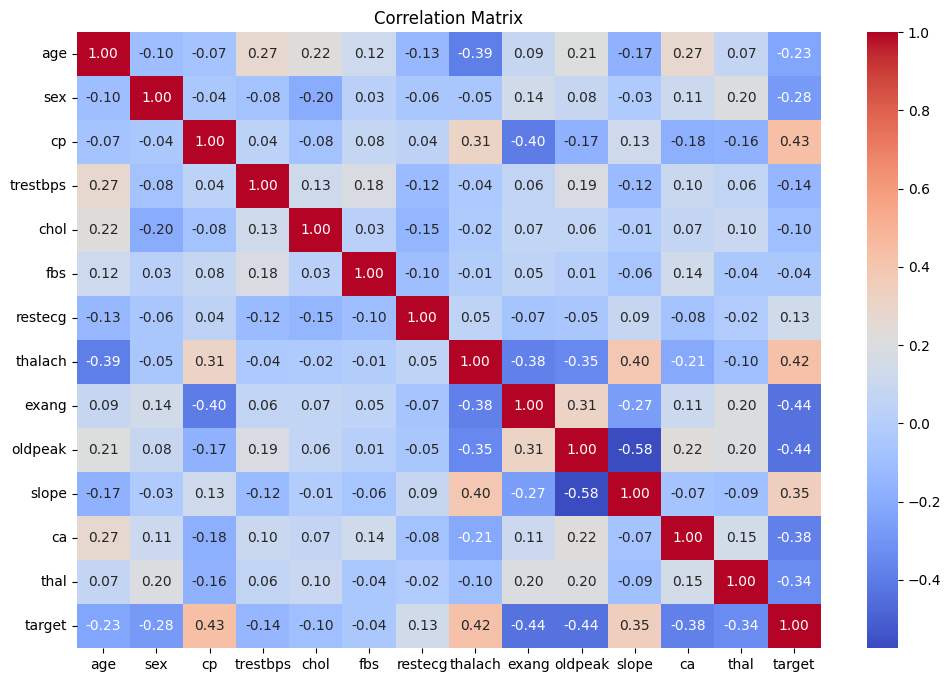

In [ ]:
plt.figure(figsize=(12, 8)) #задаем размеры графика
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap="coolwarm") #с помощью библиотеки seaborn изображаем данные
plt.title("Correlation Matrix") #даем названием
plt.show() #выводим на экран

---
*Чтобы проанализировать данную базу данных мы поставили себе вопросы, на которые хотели бы получить ответы. В зависимости от вопроса мы будем использовать различные функции, методы и модели, чтобы корректро и правильно ответить на поставленные задачи*

---

# *Как возраст пациентов распределён среди больных и здоровых? Есть ли тенденция, что болезнь чаще встречается у пожилых?*

---

*В данном коде мы смотрим сколько всего есть заболевших и здоровых людей через функию ```.value_counts()```*

---

In [ ]:
data["target"].value_counts()


,count
target,
1,526
0,499


---
*С помоью данного кода мы выводим таблицу, где показанны данные только о больных людях, так как ```["target"]==1 ```*

---

In [ ]:
data[(data["target"]==1)]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
10,71,0,0,112,149,0,1,125,0,1.6,1,0,2,1
12,34,0,1,118,210,0,1,192,0,0.7,2,0,2,1
15,34,0,1,118,210,0,1,192,0,0.7,2,0,2,1
16,51,0,2,140,308,0,0,142,0,1.5,2,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1011,45,1,1,128,308,0,0,170,0,0.0,2,0,2,1
1014,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
1019,47,1,0,112,204,0,1,143,0,0.1,2,0,2,1
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1


---

*Далее мы присваиваем таблице с больными и таблице со здоровыми значение переменной и строим для них гистограммы *

---

In [ ]:
datatrgt1=data[data["target"]==1]
datatrgt0=data[data["target"]==0]

---
*Далее мы выводим возраст людей и соотведствующее ему количество людей и сортируем по значениям и по индексам. Это нам нужно для того, чтобы проверить достоверность нашего графика*

---

In [ ]:
datatrgt1["age"].value_counts().sort_values()

,count
age,
40,3
61,3
74,3
70,3
76,3
29,4
34,6
37,6
69,6


In [ ]:
datatrgt1["age"].value_counts().sort_index()

,count
age,
29,4
34,6
35,8
37,6
38,8
39,10
40,3
41,29
42,22


---
*Сравнивая значения таблиц и графики, то мы правильно их построили*

---

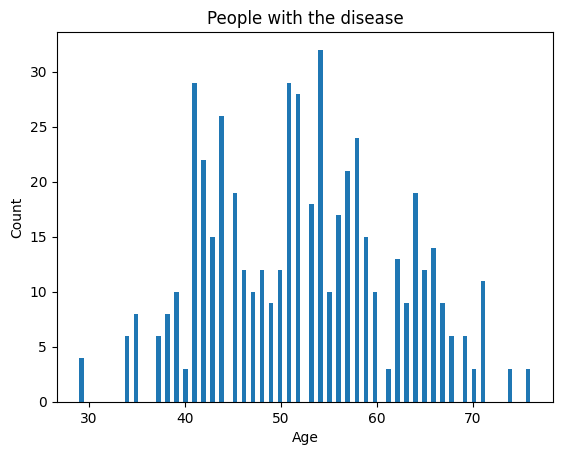

In [ ]:
datatrgt1["age"].plot(kind='hist',bins=100)

plt.title('People with the disease')
plt.ylabel('Count')
plt.xlabel('Age')
plt.show()

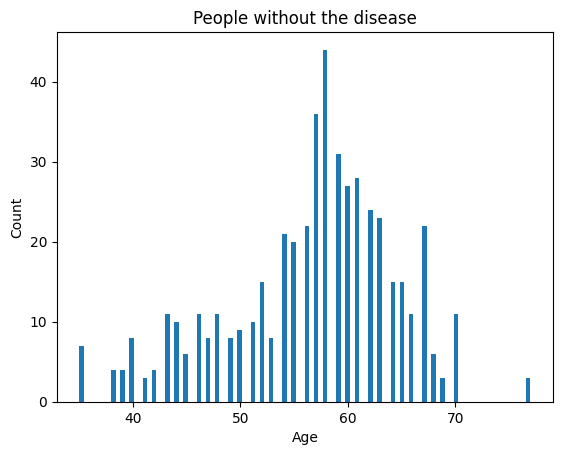

In [ ]:
datatrgt0["age"].plot(kind='hist',bins=100)

plt.title('People without the disease')
plt.ylabel('Count')
plt.xlabel('Age')
plt.show()

---
*Теперь можно изобразить 2 гистограммы вместе и сравнить результаты*

---

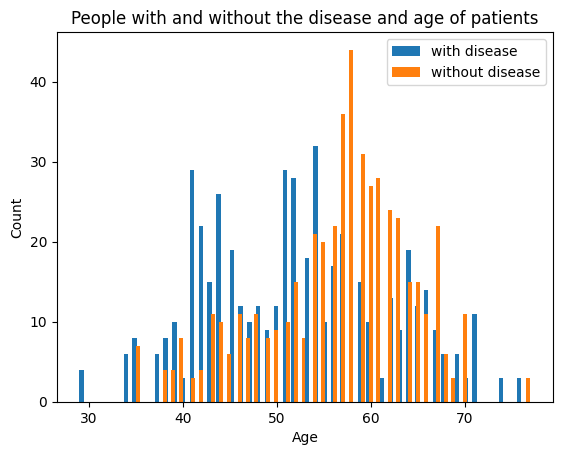

In [ ]:
datatrgt1["age"].plot(kind='hist',bins=100, label='with disease')
datatrgt0["age"].plot(kind='hist',bins=100, label="without disease")

plt.title('People with and without the disease and age of patients')
plt.ylabel('Count')
plt.xlabel('Age')
plt.legend()
plt.show()

---
*Смотря на этот график можно сделать вывод что возраст распределен от чуть меньше 30 до 70 и выше. Так же заметна тенденция что количество людей с заболеванием значительно больше, нежели людей без заболевания. Это значит что есть тенденция что люди с заболеванием являются среднего или более приклонного возраста. Так же можно сделать вывод что возраст влияет на частоту заболеваний*

---

#*Влияет ли пол пациента на вероятность сердечного заболевания? Чаще ли встречаются болезни сердца у мужчин или женщин?*



---
*Так же, как и в прошлый раз мы считаем количество мужчин и женщин, где мужчин 713, а женщин 312.*

---


In [ ]:
data.value_counts("sex")

,count
sex,
1,713
0,312


---
*Чтобы выяснить влияет ли пол пациента на вероятность сердечного заболевания, мы используем формулу ```pd.Series.corr(X,У)``` где пытаемся определить в нашем случае коэффициент корреляции между зниченниями ```data["sex"]``` и ```data["target"]```. Его значение обсуждалось раннее*

---

In [ ]:
pd.Series.corr(data["sex"], data["target"])

np.float64(-0.2795007572922625)

---

*Коэффициент корреляции -0.2795007572922625 указывает на слабую обратную линейную связь между двумя переменными. Это оначает что с возрастанием одной переменной, уменьшается другая переменная, и наоборот. Можно сделать вывод что пол не влияет на вероятность заболевания.*

НО!!!

*Данный вывод не может являться достоверным, так как в открытых источникаж информации есть тенденция что чаще такими заболеваниями страдают мужчины, нежели женщины. Это значит что в нашей базе данным может быть не достатчное количество информации для того чтобы проследить тенденцию, так как с предыдущей таблицы мы видим что мужчин у нас минимум в два раза больше. Поэтому данные не являются окончательными*

---


#*Как распределяется уровень холестерина (chol) у пациентов с болезнью и без? Можно ли выделить критические уровни холестерина?*


---
*Построим график и таблицу для того чтобы просмотреть распределение*

---

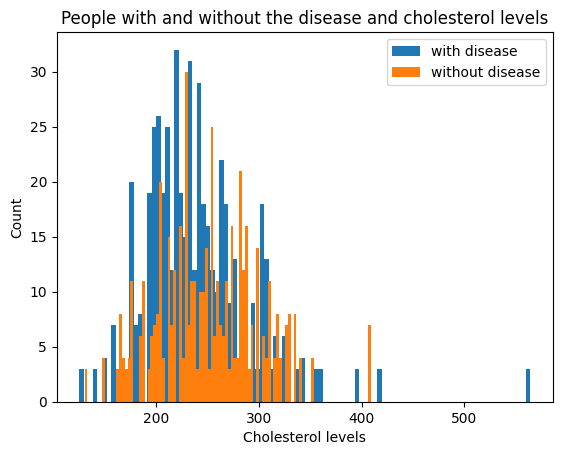

In [ ]:
datatrgt1['chol'].plot(kind='hist', bins=100, label='with disease')

datatrgt0['chol'].plot(kind='hist', bins=100, label="without disease")

plt.title('People with and without the disease and cholesterol levels')
plt.ylabel('Count')
plt.xlabel('Сholesterol levels')
plt.legend()
plt.show()

In [ ]:
datatrgt1['chol'].value_counts().sort_index()

,count
chol,
126,3
141,3
149,4
157,4
160,3
...,...
354,3
360,3
394,3


---
*Найдем критические значения*

---


In [ ]:
data["chol"].min()

126

In [ ]:
data["chol"].max()

564

---

*Уровень холестерина значительно больше у тех, кто страдает сердечными заболеваниями, в отличаи от тех, кто ими не страдает.*

---

#*Связан ли повышенный уровень сахара натощак (fbs) с сердечными заболеваниями?*




---
*Определим уровень корреляции между двумя показателями.*

---

In [ ]:
pd.Series.corr(data["fbs"], data["target"])

np.float64(-0.041163547464651264)

---

*Из данного результата можно сделать вывод, что повышенный уровень сахара не связан с сердечными заболеваниями.*

---

#*Какие признаки имеют наибольшую корреляцию с заболеванием (target)?*


---
*Для того, чтобы это выяснить, можно сразу построить таблицу корреляции и вручную просмотреть все показатели.*

---

In [ ]:
data.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.103240,-0.071966,0.271121,0.219823,0.121243,-0.132696,-0.390227,0.088163,0.208137,-0.169105,0.271551,0.072297,-0.229324
sex,-0.103240,1.000000,-0.041119,-0.078974,-0.198258,0.027200,-0.055117,-0.049365,0.139157,0.084687,-0.026666,0.111729,0.198424,-0.279501
cp,-0.071966,-0.041119,1.000000,0.038177,-0.081641,0.079294,0.043581,0.306839,-0.401513,-0.174733,0.131633,-0.176206,-0.163341,0.434854
trestbps,0.271121,-0.078974,0.038177,1.000000,0.127977,0.181767,-0.123794,-0.039264,0.061197,0.187434,-0.120445,0.104554,0.059276,-0.138772
chol,0.219823,-0.198258,-0.081641,0.127977,1.000000,0.026917,-0.147410,-0.021772,0.067382,0.064880,-0.014248,0.074259,0.100244,-0.099966
fbs,0.121243,0.027200,0.079294,0.181767,0.026917,1.000000,-0.104051,-0.008866,0.049261,0.010859,-0.061902,0.137156,-0.042177,-0.041164
restecg,-0.132696,-0.055117,0.043581,-0.123794,-0.147410,-0.104051,1.000000,0.048411,-0.065606,-0.050114,0.086086,-0.078072,-0.020504,0.134468
thalach,-0.390227,-0.049365,0.306839,-0.039264,-0.021772,-0.008866,0.048411,1.000000,-0.380281,-0.349796,0.395308,-0.207888,-0.098068,0.422895
exang,0.088163,0.139157,-0.401513,0.061197,0.067382,0.049261,-0.065606,-0.380281,1.000000,0.310844,-0.267335,0.107849,0.197201,-0.438029
oldpeak,0.208137,0.084687,-0.174733,0.187434,0.064880,0.010859,-0.050114,-0.349796,0.310844,1.000000,-0.575189,0.221816,0.202672,-0.438441


---

*Из данной таблицы показатели ```cp, thalach, slope, restecg``` имеют наибольшую корреляцию с заблеваниями.*

---

#*Как влияют тип боли в груди (cp) и результаты ЭКГ (restecg) на вероятность заболевания?*


---
*Для того, чтобы определить влияние этих показателей, нужно построить модель Логистической регресии. С помощью нее можно посмотреть, как сильно эти признаки влияют на вероятность болезни: Значения коэффициентов покажут, увеличивают ли эти признаки вероятность заболевания.*

---

In [ ]:
model = LogisticRegression()
model.fit(data[['cp', 'restecg']], data['target']) #с помощью .fit мы обучаем нашу модель

print("Коэффициенты модели:", model.coef_)

Коэффициенты модели: [[0.96062436 0.50921739]]


---
*После того, как мы построили модель, можно сделать вывод: мы получили высокие и положительные коэффициенты, что означает что эти признаки увеличивают вероятность болезни*

*cp (тип боли в груди): сильнее всего влияет на наличие заболевания.*

*restecg (результаты ЭКГ): более слабый, но иногда значимый признак.*

---

#*Можно ли по биомаркерам (возраст, холестерин, давление, ЭКГ и т. д.) предсказать наличие сердечного заболевания?*

---

*Чтобы это определить мы должны как в прошлый раз построить модель и с ее результатов сделать вывод.*

---

In [ ]:
X = data.drop("target", axis=1) # Удаляем из датафрейма последний столбец, чтобы модель не знала конечных результатов и выдавала правильные ответы
y = data["target"] # Те данные, которые предстоит угадать модели


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # мы разделяем данные на обучающую и тестовую выборки, где мы берем 20% для теста, все остальное для обучения


scaler = StandardScaler() #применяем модель стандартизации
X_train_scaled = scaler.fit_transform(X_train) #вычисляем отклонение и стандартизируем
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression() #применяем модель логистической регрессии
model.fit(X_train_scaled, y_train) #обучаем модель

# Оценка качества модели
y_pred = model.predict(X_test_scaled) #модель делает предсказания на основе тестовых данных.
print(classification_report(y_test, y_pred)) #отчет от класификации

              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



---

*Отвечая на вопрос: Да, если построить правильную модель, то можно предсказавать по биомаркерам наличие сердечного заболевания, так как построеная модель показывает 80% правильности ее результата, где можно посмотреть по accuracy.*

---

#Как изменится точность модели, если нормализовать или стандартизировать признаки?


---
*Чтобы проверить, как изменится точность, мы должны проверим модель без нормализации и стандартизации наших данных, что мы делаем далее*

---

In [ ]:
model_raw = LogisticRegression()
model_raw.fit(X_train, y_train)

print("Without Scaling:")
print(classification_report(y_test, model_raw.predict(X_test)))

Without Scaling:
              precision    recall  f1-score   support

           0       0.84      0.69      0.76       102
           1       0.74      0.87      0.80       103

    accuracy                           0.78       205
   macro avg       0.79      0.78      0.78       205
weighted avg       0.79      0.78      0.78       205



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


---
*Данная операция выдала нам результат, но нам выдало предупреждение о том, что данные могут быть меннее точные и лучше провести их стандартизацию или нормализацию*

---

---

*Далее проверим стандартизацию и нормализацию*

---

In [ ]:
scaler = StandardScaler() #стандартизация признаков
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print("With Standardization:")
print(classification_report(y_test, y_pred))


With Standardization:
              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



In [ ]:
scaler_minmax = MinMaxScaler() # нормализация признаков
X_train_minmax = scaler_minmax.fit_transform(X_train)
X_test_minmax = scaler_minmax.transform(X_test)

model_minmax = LogisticRegression()
model_minmax.fit(X_train_minmax, y_train)

print("With MinMax Normalization:")
print(classification_report(y_test, model_minmax.predict(X_test_minmax)))

With MinMax Normalization:
              precision    recall  f1-score   support

           0       0.88      0.73      0.80       102
           1       0.77      0.90      0.83       103

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205



---

*Обращая внимание на главный признак  accuracy мы види результат 80% при стандартизации и 81% при нормализации, где без испоьзования этого получали 78%.*

*Это означает, что если использовать один из 2 главных методов преобразования данных, то точность наших моделей может возрасти и соотведственно возростает эффективность модели.*

*Это крайне важно для нас, так как в данном случае нам нужно прверять показатели и делать выводы, которые напрямую зависят на жизнь человека и на постановку диагноза.*

---


#*Какое сочетание признаков даёт наилучшее качество классификации?*


In [ ]:
X = data.drop("target", axis=1) #деление на признаки и целевую переменную
y = data["target"]


best_features = SelectKBest(score_func=f_classif, k='all').fit(X, y) # с помощью SelectKBest мы находим лучшие признаки среди всех
scores = pd.Series(best_features.scores_, index=X.columns).sort_values(ascending=False) #оцениваем важность каждого признака

print("Feature scores:\n", scores)

top_features = scores.head(5) # пишем топ 5 лучших признаков
print("top 5:\n", top_features)

Feature scores:
 oldpeak     243.450780
exang       242.883889
cp          238.558457
thalach     222.799538
ca          174.877078
slope       138.679393
thal        131.802996
sex          86.689707
age          56.785135
trestbps     20.087353
restecg      18.838205
chol         10.326152
fbs           1.736352
dtype: float64
top 5:
 oldpeak    243.450780
exang      242.883889
cp         238.558457
thalach    222.799538
ca         174.877078
dtype: float64


---
*Признаки ```oldpeak, exang, cp, thalach ,ca``` и их сочетание дает наилучшее качество классификации.*

---

#*Есть ли критические значения ST-сегмента (oldpeak), при которых риск максимален?*


---
*Мы должны вывести средние значения, чтобы посмотреть с чем сравнивать.*

*Выводим средние значения по признаку oldpeak для больных и здоровых людей.*

---

In [ ]:
data.groupby('target')['oldpeak'].mean()

,oldpeak
target,
0,1.600200
1,0.569962


---

*Для здоровых людей если показатель значеня ST-сегомента больше 1.600200, то этот риск возрастает.*

*Тоже самое можно сказать и про больных людей: если показатели превышают 	0.569962, то риск возрастает.*

---




#*У каких пациентов чаще встречается заболевание: у тех, у кого изменён slope, повышен oldpeak и ca больше 0?*


---
*Чтобы это определить, мы должны выделить людей с такими признаками через определенные фильтр*

*На примере рассмотрим признак oldpeak больще или равен 0.5 (Значение взято из интернета)*

---

In [ ]:
data[data["oldpeak"]>=0.5]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016,65,1,3,138,282,1,0,174,0,1.4,1,1,2,0
1017,53,1,0,123,282,0,1,95,1,2.0,1,2,3,0
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0


In [ ]:
data[data["oldpeak"]>=0.5]["target"] #выводим столбец с заболевшими

,target
0,0
1,0
2,0
4,0
5,1
...,...
1016,0
1017,0
1021,0
1022,0


In [ ]:
data[data["oldpeak"]>=0.5]["target"].mean()*100

np.float64(35.738255033557046)

---

*Уже из отфильтрованой базы данных по признаку что oldpeak больше 0.5 мы можем выделить какая часть из них болеют сердечно-сосудистыми заболеваниями, выделив среднее значение. То есть мы выделяем долю больных людей.*

*Полученный результат нашей функции означает, что на 35% чаще встречается заболевание у людей, если у них повышено Снижение сегмента ST при нагрузке по сравнению с покоем (oldpeak)*

*Аналогично с другими признаками*

---

In [ ]:
data[data["slope"]!=0]["target"].mean()*100

np.float64(52.36593059936908)

---

*На 52% чаще встречается заболевание у людей, если у них Форма ST-сегмента при нагрузке не ровняется 0 (slope)*

---

In [ ]:
data[data["ca"]>0]["target"].mean()*100

np.float64(24.832214765100673)

---

*На 24% чаще встречается заболевание у людей, если у них Количество сосудов, окрашенных при флюороскопии от 1 и выше (са)*

---

#*Какие распределения числовых признаков (age, trestbps, chol, thalach, oldpeak) наблюдаются в подгруппах пациентов с болезнью и без болезни?*


---

*Мы должны вспомнить что ранее разбивали наш датасет на больных и здоровых людей. Чтобы отследить распределение числовых признаков, можно использовать функцию ```.describe()``` и выделить те признаки, что нас интересуют. Мы сможем увидеть всю информацию про данные признаки и так же их распределение.*

---

In [ ]:
datatrgt1.describe()[["age", "trestbps", "chol", "thalach", "oldpeak"]]

,age,trestbps,chol,thalach,oldpeak
count,526.000000,526.000000,526.000000,526.000000,526.000000
mean,52.408745,129.245247,240.979087,158.585551,0.569962
std,9.631804,16.112188,53.010345,19.096928,0.771079
min,29.000000,94.000000,126.000000,96.000000,0.000000
25%,44.000000,120.000000,208.000000,149.000000,0.000000
50%,52.000000,130.000000,234.000000,161.500000,0.200000
75%,59.000000,140.000000,265.750000,172.000000,1.000000
max,76.000000,180.000000,564.000000,202.000000,4.200000


In [ ]:
datatrgt0.describe()[["age", "trestbps", "chol", "thalach", "oldpeak"]]

,age,trestbps,chol,thalach,oldpeak
count,499.000000,499.000000,499.000000,499.000000,499.000000
mean,56.569138,134.106212,251.292585,139.130261,1.600200
std,7.908153,18.576736,49.558924,22.565235,1.290956
min,35.000000,100.000000,131.000000,71.000000,0.000000
25%,52.000000,120.000000,217.000000,125.000000,0.600000
50%,58.000000,130.000000,249.000000,142.000000,1.400000
75%,62.000000,144.000000,284.000000,156.000000,2.500000
max,77.000000,200.000000,409.000000,195.000000,6.200000


---

*По нашему желаю мы хотим визуализировать полученные результаты. Чтобы не писать код, где много лишнего и много елементов одинаковы и лишь изменяются признаки, мы для этой задачи использовуем цикл for, чтобы упростить визуализацию наших данных.*

*То есть данный код универсален, так как зависит от количества переменных и не требует дополнительной работы. Если у  нас будет необходимость добавить или убрать признак, это можно сделать в одной строке, не изменяя и не удаляя большие фрагменты кода, что очень удобно*

---


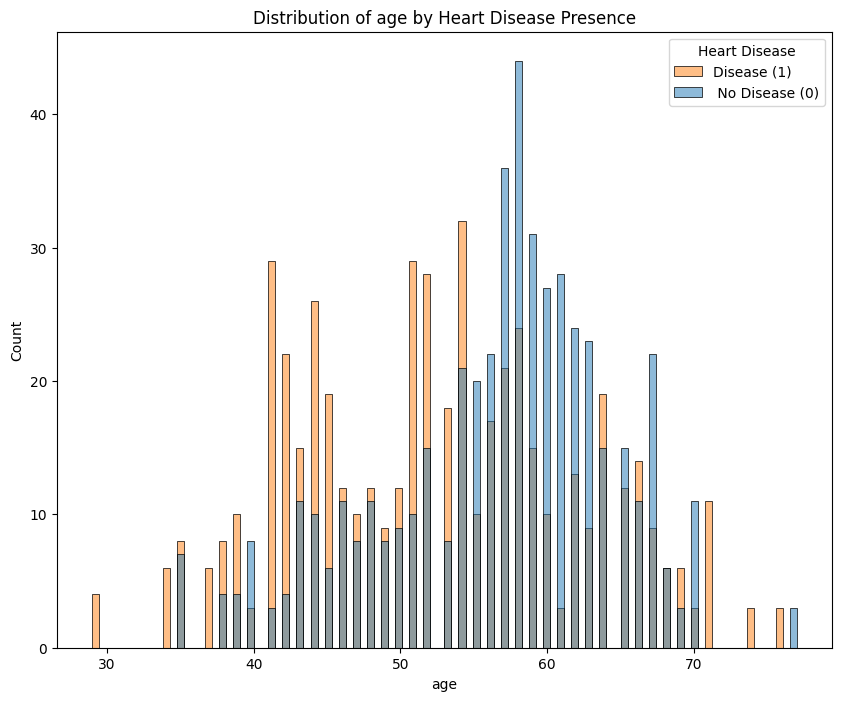

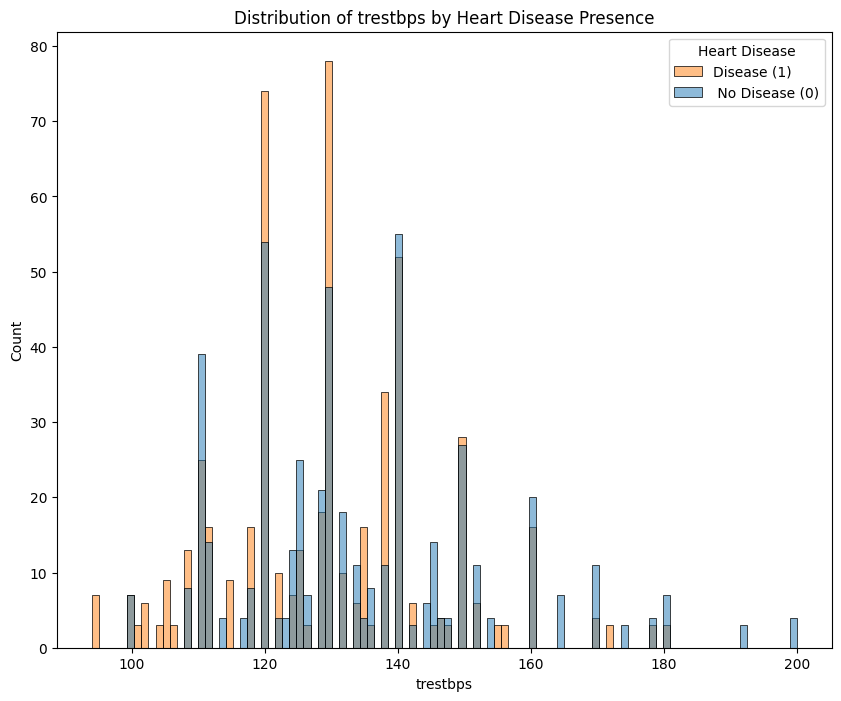

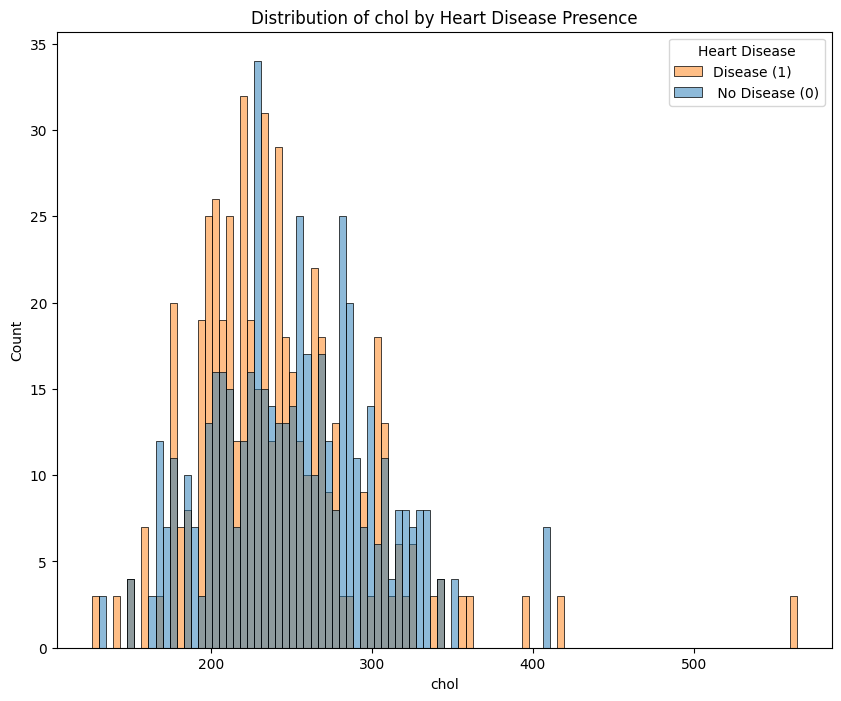

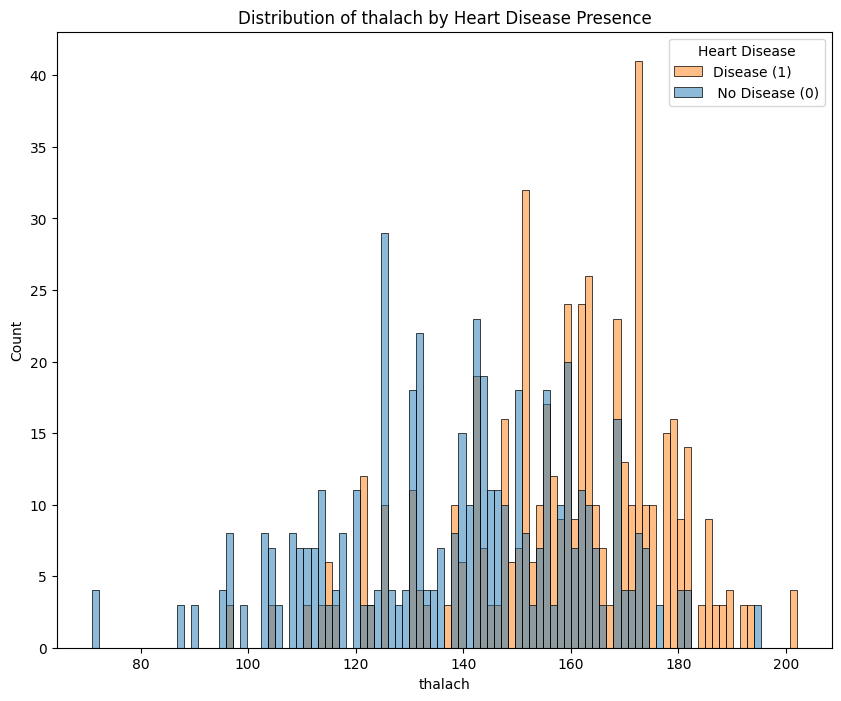

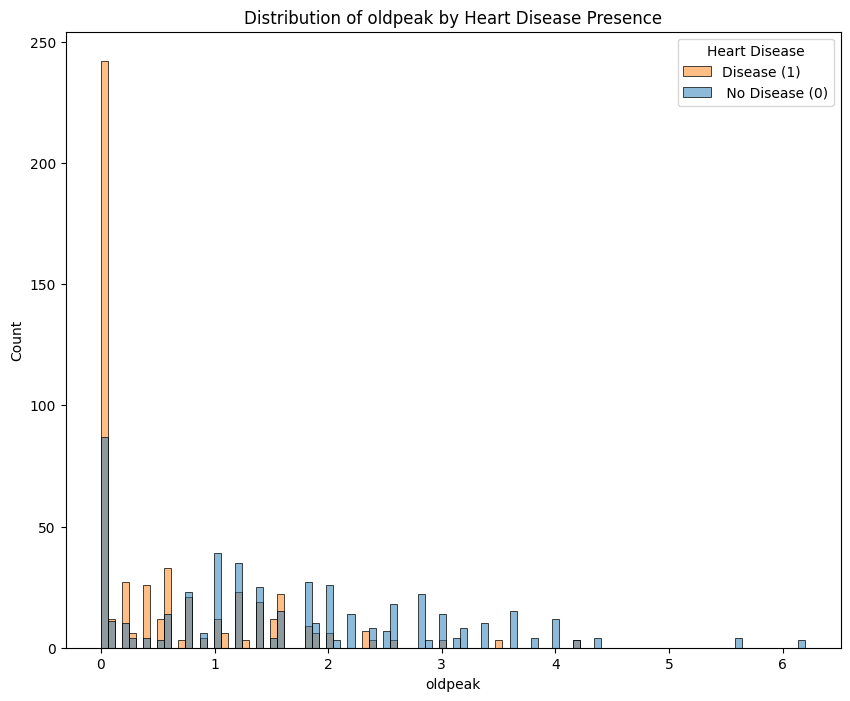

In [ ]:
features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak'] #создаем список из наших признаков, которые будем визуализировать

for feature in features: # создаем цикл где по каждому елементу списка мы поочередно будем проходить
    plt.figure(figsize=(10,8)) # задаем размеры наших графиков
    sns.histplot(data=data, x=feature, hue='target', bins=100)
    #создаем гистограммы, где берем данные из data, иследуем признак feature('age', 'trestbps'...) из features по оси х где распределяем значения на больных и здоровых

    plt.title(f'Distribution of {feature} by Heart Disease Presence') #даем названием графику и вставляем нужный признак
    plt.xlabel(feature) # подписываем ось Х
    plt.ylabel('Count') # пописываем ось У
    plt.legend(title='Heart Disease', labels=['Disease (1)', ' No Disease (0)']) # задаем легенду, где подписываем гд больные а где здоровые
    plt.show() # показываем график

#*Mожно ли с помощью корреляции и методов отбора признаков (SelectKBest, деревья решений) выделить ключевые переменные?*


---

*В прошлый разы мы использовали SelectKBest и матрицы корреляции, в этот раз можно использовать деревья решений*

---

In [ ]:
tree = DecisionTreeClassifier(random_state=42) # Обучаем дерево решений
tree.fit(X, y)

feature_importances = pd.Series(tree.feature_importances_, index=X.columns).sort_values(ascending=False)
# находим важность признаков из модели дерева через функцию .feature_importances_ и сортируем их
print("Feature importance (Decision Tree):\n", feature_importances)

Feature importance (Decision Tree):
 cp          0.270006
ca          0.155398
oldpeak     0.100665
chol        0.088038
thal        0.080872
age         0.079670
trestbps    0.051714
thalach     0.043401
sex         0.037490
slope       0.033580
exang       0.030011
restecg     0.018727
fbs         0.010428
dtype: float64


---

*Дерево показывает, какие признаки модель использует в первую очередь для разделения классов.*

---

*Сделав вывод из этого и предыдущих вычислений, можно сказать что да: с помощью этих всех методов отбора признаков можно выделить ключевые переменные. И если посмотреть какие переменые повторяются, можно с уверенностью сказать что эти признаки ключевые*

---

#Насколько точно модели (Logistic Regression, Decision Tree, KNN) могут предсказывать наличие болезни сердца?
#Какие метрики качества (accuracy, precision, recall, F1-score, ROC-AUC) дают лучшее представление о прогнозе?


---
*Построим уже устоявшиеся шаги для написания модели и используем модели Logistic Regression, Decision Tree, KNN*

---

In [ ]:
X = data.drop('target', axis=1)
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model_LR = LogisticRegression()
model_LR.fit(X_train_scaled, y_train)
y_pred = model_LR.predict(X_test_scaled)
roc_auc_LR = roc_auc_score(y_test, model_LR.predict_proba(X_test_scaled)[:, 1])

print("test_size=0.2")
print("Logistic Regression")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_LR, 4))

print()


model_DT= DecisionTreeClassifier()
model_DT.fit(X_train_scaled, y_train)
y_pred = model_DT.predict(X_test_scaled)
roc_auc_DT = roc_auc_score(y_test, model_DT.predict_proba(X_test_scaled)[:, 1])

print("Decision Tree")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_DT, 4))

print()


model_KNN= KNeighborsClassifier()
model_KNN.fit(X_train_scaled, y_train)
y_pred = model_KNN.predict(X_test_scaled)
roc_auc_KNN = roc_auc_score(y_test, model_KNN.predict_proba(X_test_scaled)[:, 1])

print("KNN")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_KNN, 4))



test_size=0.2
Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205

ROC-AUC: 0.8787

Decision Tree
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205

ROC-AUC: 0.9854

KNN
              precision    recall  f1-score   support

           0       0.88      0.77      0.82       102
           1       0.80      0.89      0.84       103

    accuracy                           0.83       205
   macro avg       0.84      0.83      0.8

---
*Модели Logistic Regression, Decision Tree, KNN могут довольно точно предсказывать наличие болезни сердца, показывая это через параметр ```roc_auc``` насколько модель хорошо различает больных и здоровых (чем ближе к 1.0, тем лучше)*


*Чтобы иметь лучшее представления о прогнозе, стоит учитывать характеристики тех метрик, которые мы получили:*

*```аccuracy``` — общий процент верных предсказаний.*

*```рrecision``` — насколько часто модель ошибается, говоря что человек болен.*

*```recall``` — насколько часто модель правильно находит больных.*

*```f1-score``` — среднее между precision и recall.*

*```roc-auc``` — общий показатель надёжности модели.*

*В предсказаниях сердечных заболеваний особенно важны Recall, F1-score и ROC-AUC. Они помогают не пропустить больных и оценить надёжность модели.*

---

#*Как изменяется надёжность модели, если использовать разные пропорции данных для обучения и тестирования?*


---
*Для того, чтобы это проследить, будем увеличивать пропорции данных для иследования, увеличивая парамент test_size*

---


In [ ]:
X = data.drop('target', axis=1)
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model_LR = LogisticRegression()
model_LR.fit(X_train_scaled, y_train)
y_pred = model_LR.predict(X_test_scaled)
roc_auc_LR = roc_auc_score(y_test, model_LR.predict_proba(X_test_scaled)[:, 1])

print("test_size=0.3")
print("Logistic Regression")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_LR, 4))

print()


model_DT= DecisionTreeClassifier()
model_DT.fit(X_train_scaled, y_train)
y_pred = model_DT.predict(X_test_scaled)
roc_auc_DT = roc_auc_score(y_test, model_DT.predict_proba(X_test_scaled)[:, 1])

print("Decision Tree")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_DT, 4))

print()


model_KNN= KNeighborsClassifier()
model_KNN.fit(X_train_scaled, y_train)
y_pred = model_KNN.predict(X_test_scaled)
roc_auc_KNN = roc_auc_score(y_test, model_KNN.predict_proba(X_test_scaled)[:, 1])

print("KNN")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_KNN, 4))



test_size=0.3
Logistic Regression
              precision    recall  f1-score   support

           0       0.86      0.75      0.80       159
           1       0.76      0.87      0.81       149

    accuracy                           0.81       308
   macro avg       0.81      0.81      0.80       308
weighted avg       0.81      0.81      0.80       308

ROC-AUC: 0.8968

Decision Tree
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       159
           1       1.00      0.94      0.97       149

    accuracy                           0.97       308
   macro avg       0.97      0.97      0.97       308
weighted avg       0.97      0.97      0.97       308

ROC-AUC: 0.9698

KNN
              precision    recall  f1-score   support

           0       0.87      0.82      0.84       159
           1       0.82      0.87      0.84       149

    accuracy                           0.84       308
   macro avg       0.84      0.84      0.8

In [ ]:
X = data.drop('target', axis=1)
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model_LR = LogisticRegression()
model_LR.fit(X_train_scaled, y_train)
y_pred = model_LR.predict(X_test_scaled)
roc_auc_LR = roc_auc_score(y_test, model_LR.predict_proba(X_test_scaled)[:, 1])

print("test_size=0.4")
print("Logistic Regression")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_LR, 4))

print()


model_DT= DecisionTreeClassifier()
model_DT.fit(X_train_scaled, y_train)
y_pred = model_DT.predict(X_test_scaled)
roc_auc_DT = roc_auc_score(y_test, model_DT.predict_proba(X_test_scaled)[:, 1])

print("Decision Tree")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_DT, 4))

print()


model_KNN= KNeighborsClassifier()
model_KNN.fit(X_train_scaled, y_train)
y_pred = model_KNN.predict(X_test_scaled)
roc_auc_KNN = roc_auc_score(y_test, model_KNN.predict_proba(X_test_scaled)[:, 1])

print("KNN")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_KNN, 4))



test_size=0.4
Logistic Regression
              precision    recall  f1-score   support

           0       0.82      0.78      0.80       202
           1       0.79      0.84      0.81       208

    accuracy                           0.81       410
   macro avg       0.81      0.81      0.81       410
weighted avg       0.81      0.81      0.81       410

ROC-AUC: 0.9029

Decision Tree
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       202
           1       0.98      0.97      0.98       208

    accuracy                           0.98       410
   macro avg       0.98      0.98      0.98       410
weighted avg       0.98      0.98      0.98       410

ROC-AUC: 0.9757

KNN
              precision    recall  f1-score   support

           0       0.86      0.82      0.84       202
           1       0.83      0.87      0.85       208

    accuracy                           0.85       410
   macro avg       0.85      0.85      0.8

In [ ]:
X = data.drop('target', axis=1)
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model_LR = LogisticRegression()
model_LR.fit(X_train_scaled, y_train)
y_pred = model_LR.predict(X_test_scaled)
roc_auc_LR = roc_auc_score(y_test, model_LR.predict_proba(X_test_scaled)[:, 1])

print("test_size=0.5")
print("Logistic Regression")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_LR, 4))

print()



model_DT= DecisionTreeClassifier()
model_DT.fit(X_train_scaled, y_train)
y_pred = model_DT.predict(X_test_scaled)
roc_auc_DT = roc_auc_score(y_test, model_DT.predict_proba(X_test_scaled)[:, 1])

print("Decision Tree")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_DT, 4))

print()


model_KNN= KNeighborsClassifier()
model_KNN.fit(X_train_scaled, y_train)
y_pred = model_KNN.predict(X_test_scaled)
roc_auc_KNN = roc_auc_score(y_test, model_KNN.predict_proba(X_test_scaled)[:, 1])

print("KNN")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_KNN, 4))

test_size=0.5
Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.76      0.80       254
           1       0.79      0.86      0.83       259

    accuracy                           0.81       513
   macro avg       0.82      0.81      0.81       513
weighted avg       0.82      0.81      0.81       513

ROC-AUC: 0.9114

Decision Tree
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       254
           1       0.96      0.95      0.96       259

    accuracy                           0.96       513
   macro avg       0.96      0.96      0.96       513
weighted avg       0.96      0.96      0.96       513

ROC-AUC: 0.9552

KNN
              precision    recall  f1-score   support

           0       0.88      0.81      0.84       254
           1       0.82      0.89      0.86       259

    accuracy                           0.85       513
   macro avg       0.85      0.85      0.8

---
*Чтобы ответить на этот вопрос, мы должны рассмотреть каждую модель по отдельности:*

*Для Logistic Regression показатели метрик качества либо остались прежними, либо возросли, что означает что для этой модели увеличение данных сделало модель более надежной.*

*Для Decision Tree показатели метрик качества имеют переменчивый характер, что означает что для этой модели увеличение данных не дано особого результата.*

*Для KNN показатели метрик качества имеют интересный характер,а именно: показатели precision, recall, f1-score, support и accuracy колеблятся, но остаются на том же уровне,  а общий показатель ROC-AUC становится ниже. Это означает что для этой модели увеличение данных сделало модель меннее надежной.*

---

#*Являются ли полученные прогнозы стабильными при разных вариантах случайного разбиения данных на обучающие и проверочные подмножества?*


In [ ]:
X = data.drop('target', axis=1)
y = data['target']


for i in range(0, 11, 3):

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)

  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)


  model_LR = LogisticRegression()
  model_LR.fit(X_train_scaled, y_train)
  y_pred = model_LR.predict(X_test_scaled)
  roc_auc_LR = roc_auc_score(y_test, model_LR.predict_proba(X_test_scaled)[:, 1])

  print("test_size=0.2")
  print("random_state", i)
  print()
  print("Logistic Regression")
  print(classification_report(y_test, y_pred))
  print("ROC-AUC:", round(roc_auc_LR, 4))

  print()

  model_DT= DecisionTreeClassifier()
  model_DT.fit(X_train_scaled, y_train)
  y_pred = model_DT.predict(X_test_scaled)
  roc_auc_DT = roc_auc_score(y_test, model_DT.predict_proba(X_test_scaled)[:, 1])

  print("Decision Tree")
  print(classification_report(y_test, y_pred))
  print("ROC-AUC:", round(roc_auc_DT, 4))

  print()

  model_KNN= KNeighborsClassifier()
  model_KNN.fit(X_train_scaled, y_train)
  y_pred = model_KNN.predict(X_test_scaled)
  roc_auc_KNN = roc_auc_score(y_test, model_KNN.predict_proba(X_test_scaled)[:, 1])

  print("KNN")
  print(classification_report(y_test, y_pred))
  print("ROC-AUC:", round(roc_auc_KNN, 4))
  print()
  print()
  print()

test_size=0.2
random_state 0

Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.79      0.85        98
           1       0.83      0.93      0.88       107

    accuracy                           0.86       205
   macro avg       0.87      0.86      0.86       205
weighted avg       0.87      0.86      0.86       205

ROC-AUC: 0.9395

Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        98
           1       1.00      1.00      1.00       107

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205

ROC-AUC: 1.0

KNN
              precision    recall  f1-score   support

           0       0.89      0.86      0.88        98
           1       0.87      0.91      0.89       107

    accuracy                           0.88       205
   macro avg       0.88      

---

*Наблюдая изменения наших показателей в зависимости от того как у нас увеличивается количество разбиений, можно сделать вывод, что различные варианты разбиение не влияют на надежность конкретных моделей в нашем случае и они остаются также стабильными*

---



#Вывод

---

*В результате выполнения данной работы была реализована полная процедура анализа медицинского датасета, направленная на выявление сердечных заболеваний на основе биомаркеров с применением методов машинного обучения.*

*Проведено исследование распределений и корреляций признаков, осуществлён отбор наиболее информативных переменных с использованием статистических методов и моделей. Выполнена предобработка данных, включая стандартизацию и нормализацию, что позволило улучшить качество классификации. Построены и сравнены несколько моделей (логистическая регрессия, дерево решений, KNN), для которых рассчитаны ключевые метрики качества: accuracy, precision, recall, F1-score и ROC-AUC.*

*Анализ показал, что по биомаркерам (таким как возраст, давление, холестерин, частота пульса, результаты ЭКГ и др.) возможно с высокой степенью точности предсказывать наличие сердечного заболевания. Кроме того, была исследована устойчивость модели к различным вариантам случайного разбиения данных, что позволило оценить её стабильность и обобщающую способность.*

*Таким образом, проделанная работа подтверждает эффективность использования методов машинного обучения для предварительной диагностики сердечно-сосудистых заболеваний на основе доступных клинических показателей.*

---